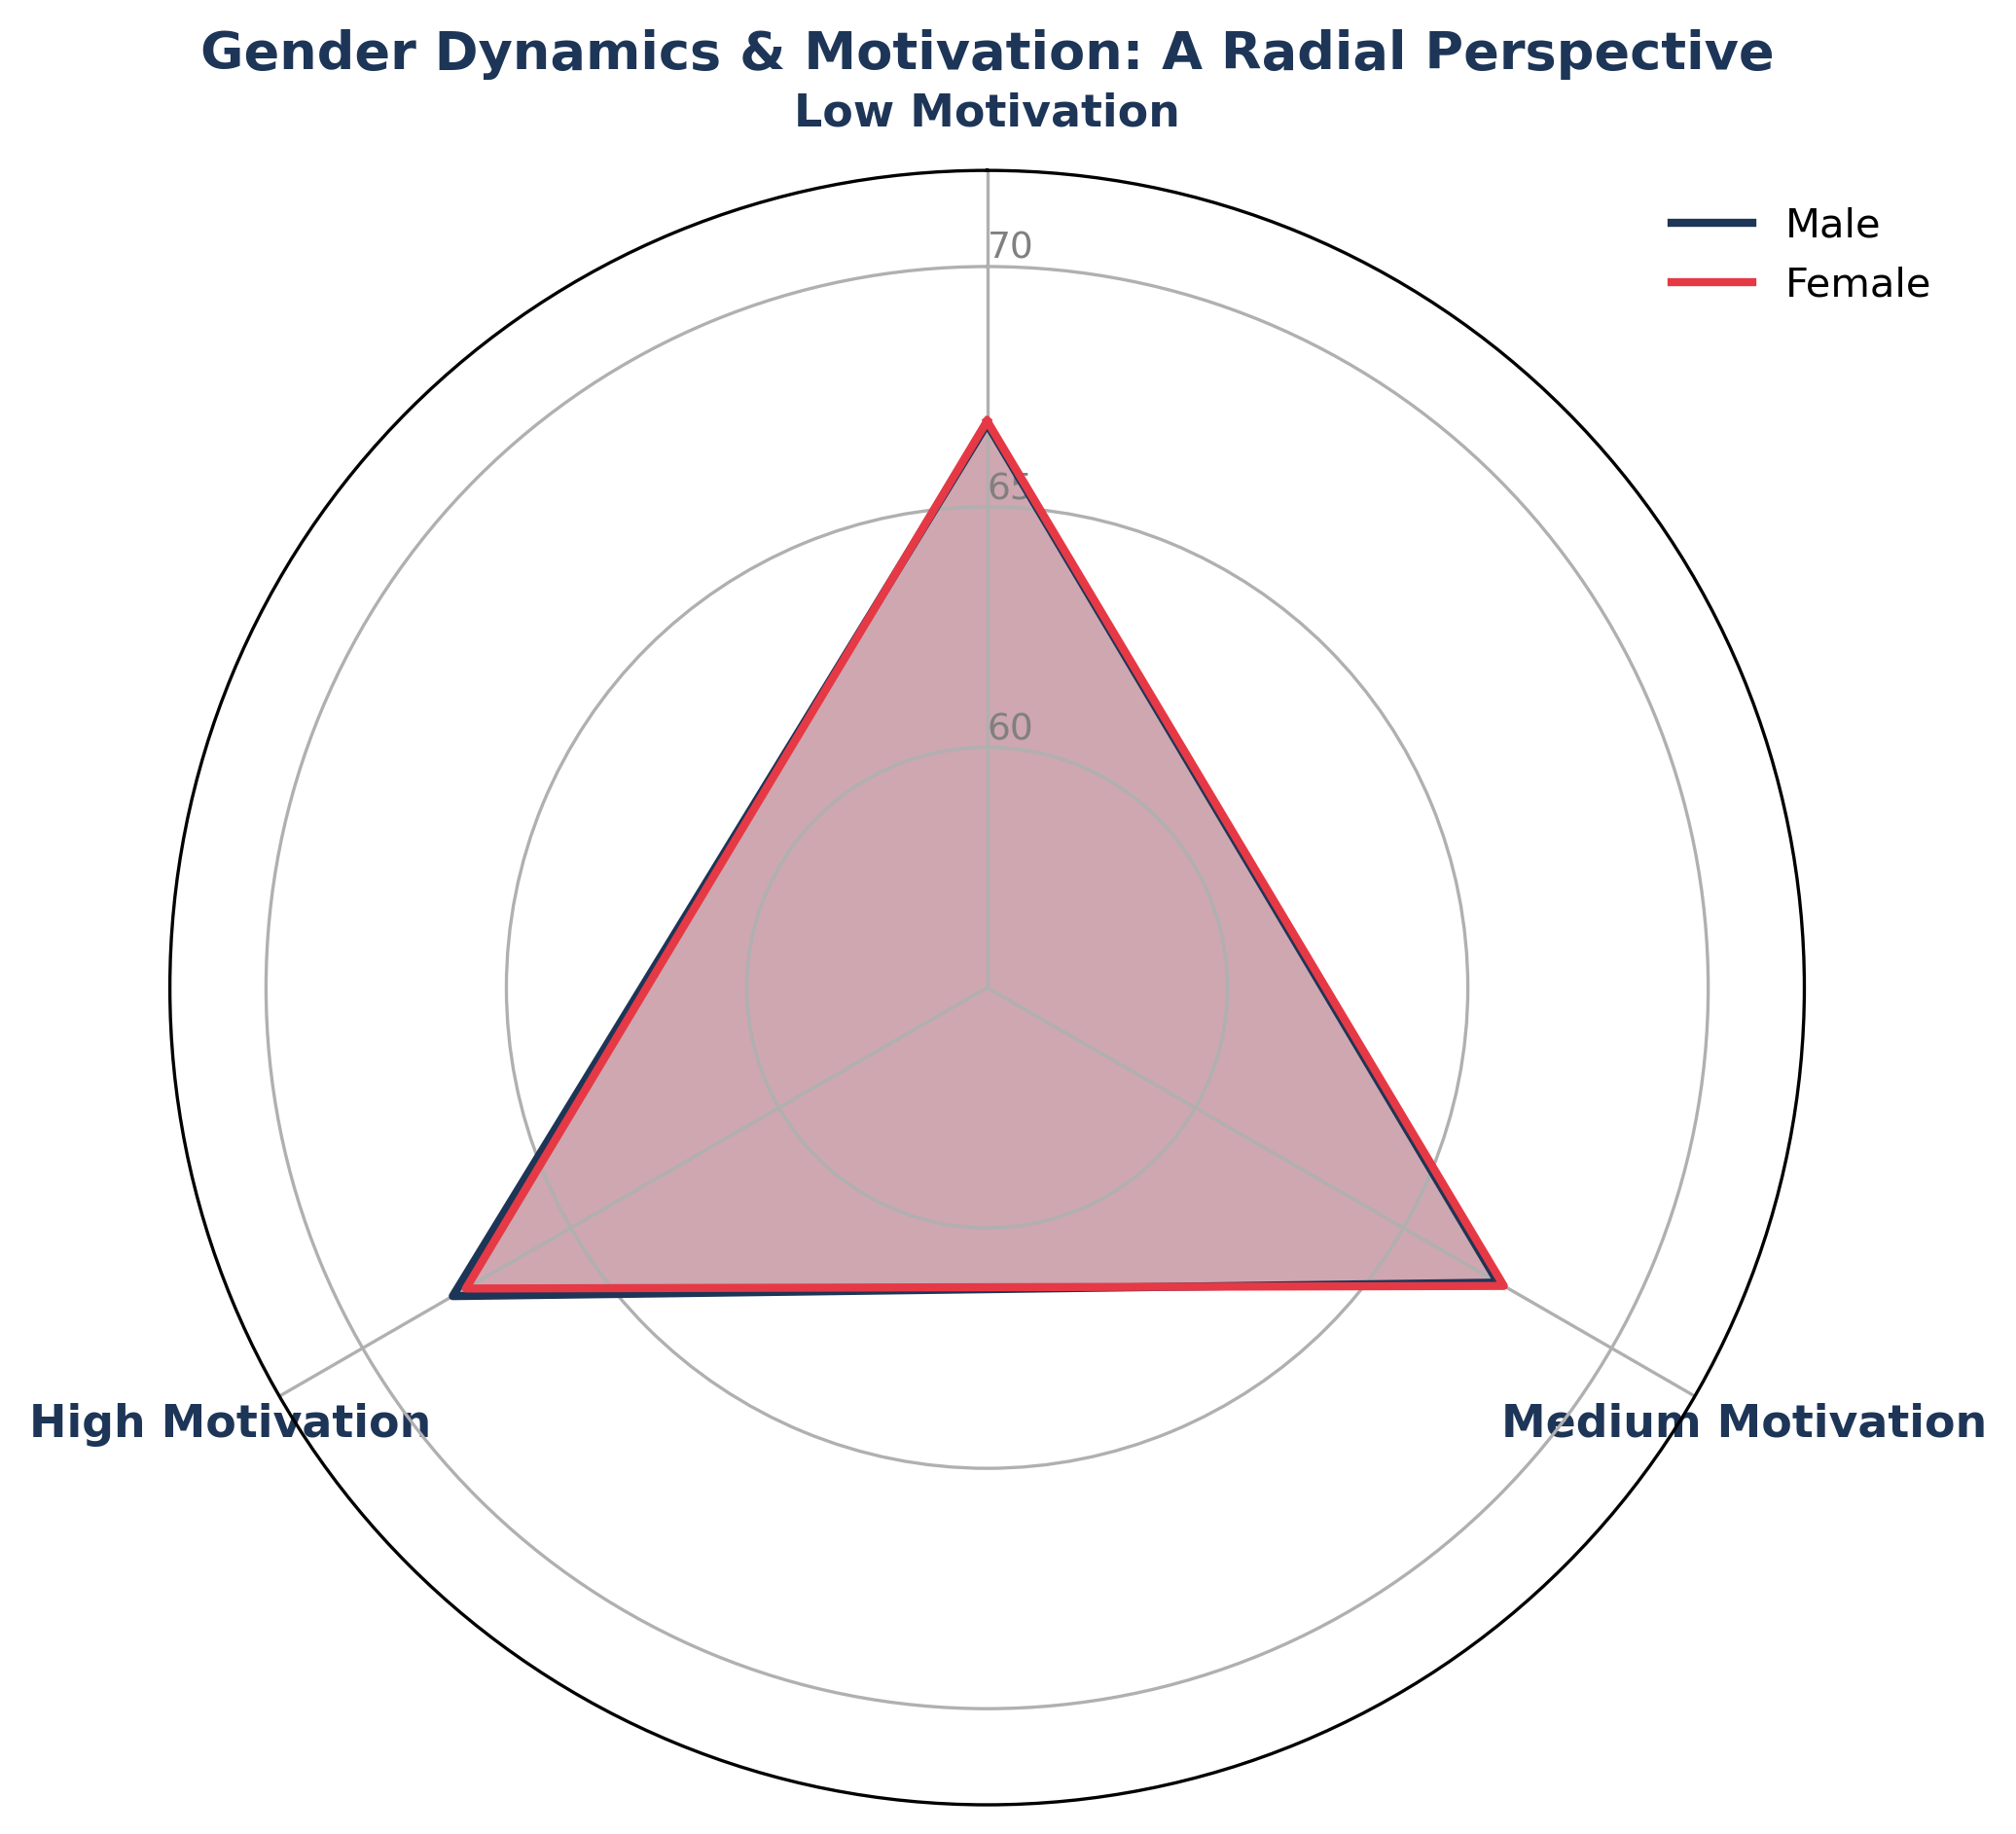

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('StudentPerformanceFactors.csv')

grouped_gender = df.groupby(['Gender', 'Motivation_Level'])['Exam_Score'].agg(['mean', 'count']).reset_index()

labels = ['Low Motivation', 'Medium Motivation', 'High Motivation']
male_scores = df[df['Gender'] == 'Male'].groupby('Motivation_Level')['Exam_Score'].mean().reindex(['Low', 'Medium', 'High']).values
female_scores = df[df['Gender'] == 'Female'].groupby('Motivation_Level')['Exam_Score'].mean().reindex(['Low', 'Medium', 'High']).values

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
male_scores = np.concatenate((male_scores, [male_scores[0]]))
female_scores = np.concatenate((female_scores, [female_scores[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True), dpi=300)

ax.plot(angles, male_scores, color='#1D3557', linewidth=2, label='Male')
ax.fill(angles, male_scores, color='#1D3557', alpha=0.25)

ax.plot(angles, female_scores, color='#E63946', linewidth=2, label='Female')
ax.fill(angles, female_scores, color='#E63946', alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], labels, color='#1D3557', size=11, weight='bold')
ax.set_rlabel_position(0)
plt.yticks([60, 65, 70], ["60", "65", "70"], color="grey", size=9)
plt.ylim(55, 72)

plt.title("Gender Dynamics & Motivation: A Radial Perspective", fontsize=13, fontweight='bold', pad=25, color='#1D3557')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.0), frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()